In [5]:
!pip install yfinance 

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


[*********************100%***********************]  1 of 1 completed


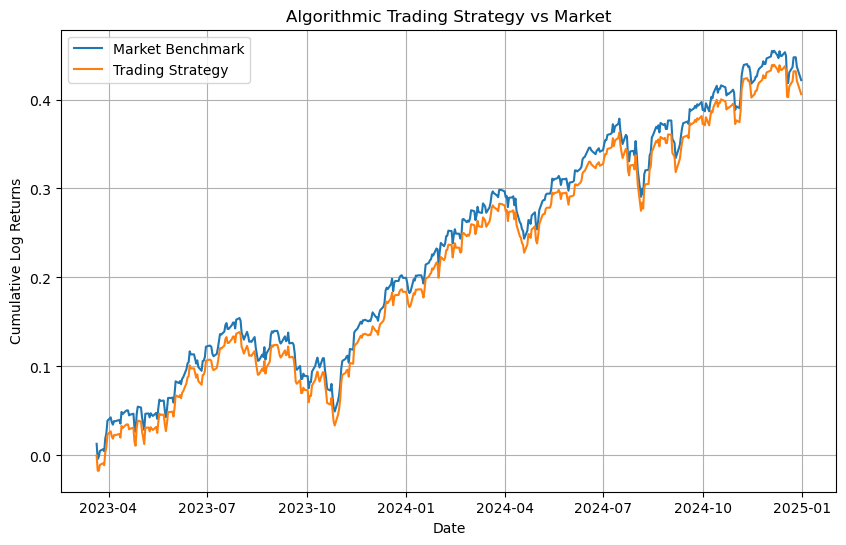

Model RMSE (Return Forecast): 0.007595
Final Market Return: 0.4218
Final Strategy Return: 0.406


In [56]:
# =====================================================
# ALGORITHMIC TRADING PROJECT
# Clean, Warning-Free Implementation
# =====================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)

# -----------------------------------------------------
# 1. DOWNLOAD FINANCIAL MARKET DATA
# -----------------------------------------------------
ticker = "SPY"          # S&P 500 ETF
start_date = "2016-01-01"
end_date = "2025-01-01"

data = yf.download(ticker, start=start_date, end=end_date,auto_adjust=False )[['Adj Close']]

# Enforce proper datetime index and frequency
data.index = pd.to_datetime(data.index)
data = data.asfreq("B")  # Business-day frequency

# Forward-fill missing prices (market holidays)
data['Adj Close'] = data['Adj Close'].ffill()

# -----------------------------------------------------
# 2. FEATURE ENGINEERING
# -----------------------------------------------------
data['Log_Return'] = np.log(data['Adj Close'] / data['Adj Close'].shift(1))
data['Rolling_Volatility'] = data['Log_Return'].rolling(window=21).std()

data.dropna(inplace=True)

# -----------------------------------------------------
# 3. TRAIN / TEST SPLIT
# -----------------------------------------------------
split = int(len(data) * 0.8)

train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

# -----------------------------------------------------
# 4. RETURN FORECASTING MODEL (ARIMA)
# -----------------------------------------------------
model = ARIMA(train['Log_Return'], order=(1, 0, 1))
fitted_model = model.fit()

forecast_returns = fitted_model.forecast(steps=len(test))
test['Forecast_Return'] = forecast_returns.values

# -----------------------------------------------------
# 5. TRADING STRATEGY
# -----------------------------------------------------
# Long-only strategy:
# Go long if forecasted return > 0

test['Signal'] = (test['Forecast_Return'] > 0).astype(int)
test['Strategy_Return'] = test['Signal'] * test['Log_Return']

# -----------------------------------------------------
# 6. PERFORMANCE METRICS
# -----------------------------------------------------
test['Cumulative_Market_Return'] = test['Log_Return'].cumsum()
test['Cumulative_Strategy_Return'] = test['Strategy_Return'].cumsum()

rmse = np.sqrt(mean_squared_error(test['Log_Return'], test['Forecast_Return']))

# -----------------------------------------------------
# 7. VISUALISATION
# -----------------------------------------------------
plt.plot(test.index, test['Cumulative_Market_Return'], label="Market Benchmark")
plt.plot(test.index, test['Cumulative_Strategy_Return'], label="Trading Strategy")
plt.title("Algorithmic Trading Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Returns")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------------------------
# 8. OUTPUT RESULTS
# -----------------------------------------------------
print("Model RMSE (Return Forecast):", round(rmse, 6))
print("Final Market Return:", round(test['Cumulative_Market_Return'].iloc[-1], 4))
print("Final Strategy Return:", round(test['Cumulative_Strategy_Return'].iloc[-1], 4))
